# 🚆❄️ Finland Integrated Train–Weather Dataset (FI-TW) — EDA

**Dataset:** [Finland Integrated Train Weather Dataset (FI-TW)](https://www.kaggle.com/datasets/viniborin/finland-integrated-train-weather-dataset-fi-tw)  
**Paper:** *Integrating Meteorological and Operational Data: A Novel Approach to Understanding Railway Delays in Finland* (arXiv:2601.16592)

This dataset integrates:
- **Railway operations** from [Digitraffic](https://www.digitraffic.fi/en/railway/) (Fintraffic)
- **Meteorological observations** from [FMI](https://en.ilmatieteenlaitos.fi/) (Finnish Meteorological Institute)

Each row represents a single train stop matched to the nearest environmental monitoring station (EMS) via Haversine distance. 

| Category | Examples |
|----------|----------|
| **Target** | `differenceInMinutes`, `cancelled` |
| **Operational** | `trainType`, `stationShortCode`, `departureDate`, `commercialStop`, `trainStopping`, `train_id` |
| **Weather** | `air_temp`, `wind_speed`, `wind_gust`, `precipitation_1h`, `snow_depth`, `visibility`, `cloud_cover` |
| **Engineered** | `month_sin/cos`, `hour_sin/cos`, `dow_sin/cos` |

**Period covered in this notebook:** January 1 – June 30, 2024

---

## 1 · Setup and Imports

We import the standard data-science stack plus `glob` for multi-file discovery and `warnings` to suppress noisy FutureWarnings that pandas occasionally emits.

In [7]:
import ast
import glob
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ── Global visual style ───────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.figsize": (13, 5),
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
})

SEED = 42
rng  = np.random.default_rng(SEED)
print("Libraries loaded ✓")

Libraries loaded ✓


---
## 2 · Loading, Concatenating, and Filtering the Data

### 2.1 · File Discovery

`glob` collects all six monthly CSVs in one pattern-match. Sorting ensures the files are processed in chronological order, which makes debugging easier.

In [3]:
DATA_FILES = sorted(glob.glob("matched_data_2024_*.csv"))

if not DATA_FILES:
    raise FileNotFoundError(
        "No files matching 'matched_data_2024_*.csv' found in the current directory. "
        "Download the dataset from https://www.kaggle.com/datasets/viniborin/"
        "finland-integrated-train-weather-dataset-fi-tw and place the CSV files "
        "in the same folder as this notebook."
    )

print(f"Found {len(DATA_FILES)} file(s):")
for f in DATA_FILES:
    print(f"  • {f}")

Found 6 file(s):
  • matched_data_2024_01.csv
  • matched_data_2024_02.csv
  • matched_data_2024_03.csv
  • matched_data_2024_04.csv
  • matched_data_2024_05.csv
  • matched_data_2024_06.csv


### 2.2 · Load and Concatenate

We read every file with `dtype=str` first — this prevents pandas from silently misinterpreting mixed-type columns (e.g. a boolean-looking column that actually contains `"true"` strings). After concatenation we cast each column to its correct type explicitly.

In [8]:
def _parse_time_table_rows(value):
    """Return a list of stop dictionaries from the timeTableRows field."""
    if isinstance(value, list):
        return value

    if isinstance(value, dict):
        return [value]

    if pd.isna(value):
        return []

    text = str(value).strip()
    if not text:
        return []

    # The exported CSV stores Python-like repr strings, so make them safe for literal_eval.
    text = re.sub(r'(?<![A-Za-z_])nan(?![A-Za-z_])', 'None', text)
    parsed = ast.literal_eval(text)
    return parsed if isinstance(parsed, list) else [parsed]

chunks = []
for path in DATA_FILES:
    chunk = pd.read_csv(path, dtype=str, low_memory=False)
    if "timeTableRows" in chunk.columns:
        expanded_rows = []
        base_columns = [c for c in chunk.columns if c != "timeTableRows"]
        for _, row in chunk.iterrows():
            base = row[base_columns].to_dict()
            stops = _parse_time_table_rows(row["timeTableRows"])
            if not stops:
                expanded_rows.append(base)
                continue
            for stop in stops:
                merged = base.copy()
                merged.update(stop)
                weather = merged.pop("weather_observations", None)
                if isinstance(weather, dict):
                    merged.update(weather)
                expanded_rows.append(merged)
        chunk = pd.DataFrame.from_records(expanded_rows)
    chunks.append(chunk)
    print(f"  {path}: {len(chunk):,} rows  ×  {chunk.shape[1]} cols")

raw = pd.concat(chunks, ignore_index=True)
print(f"\nCombined shape before filtering: {raw.shape}")
print("Columns:", raw.columns.tolist())

  matched_data_2024_01.csv: 542,978 rows  ×  56 cols
  matched_data_2024_02.csv: 506,176 rows  ×  56 cols
  matched_data_2024_03.csv: 535,222 rows  ×  56 cols
  matched_data_2024_04.csv: 518,174 rows  ×  56 cols
  matched_data_2024_05.csv: 515,164 rows  ×  56 cols
  matched_data_2024_06.csv: 495,040 rows  ×  56 cols

Combined shape before filtering: (3112754, 56)
Columns: ['trainNumber', 'departureDate', 'operatorUICCode', 'operatorShortCode', 'trainType', 'trainCategory', 'commuterLineID', 'runningCurrently', 'cancelled', 'version', 'timetableType', 'timetableAcceptanceDate', 'stationName', 'stationShortCode', 'stationUICCode', 'countryCode', 'type', 'trainStopping', 'commercialStop', 'commercialTrack', 'scheduledTime', 'actualTime', 'differenceInMinutes', 'differenceInMinutes_offset', 'differenceInMinutes_eachStation_offset', 'causes', 'trainReady', 'closest_ems', 'Air temperature', 'Wind speed', 'Gust speed', 'Wind direction', 'Relative humidity', 'Dew-point temperature', 'Precipita

### 2.3 · Column Normalisation

The paper documents two naming conventions across different FI-TW releases (`differenceInMinutes` vs `delay_minutes`, `trainType` vs `train_type`, etc.). The cell below detects whichever variant is present and standardises to snake_case aliases used throughout the rest of this notebook.

In [9]:
# ── Alias map: (possible raw name → canonical name) ───────────────────────────
ALIAS_MAP = {
    # Target
    "differenceInMinutes": "delay_minutes",
    "difference_in_minutes": "delay_minutes",
    # Operational
    "trainType":            "train_type",
    "trainNumber":          "train_number",
    "trainStopping":        "train_stopping",
    "commercialStop":       "commercial_stop",
    "stationShortCode":     "station_code",
    "station_short_code":   "station_code",
    "departureDate":        "departure_date",
    "scheduledTime":        "scheduled_time",
    "actualTime":           "actual_time",
    # Weather fields from the nested weather_observations block
    "Air temperature":      "air_temp",
    "Wind speed":           "wind_speed",
    "Gust speed":           "wind_gust",
    "Precipitation amount": "precipitation_1h",
    "Snow depth":           "snow_depth",
    "Cloud amount":         "cloud_cover",
    "Horizontal visibility":"visibility",
    # Backward-compatible aliases for other FI-TW releases
    "airTemperature":       "air_temp",
    "windSpeed":            "wind_speed",
    "windGust":             "wind_gust",
    "precipitation1h":      "precipitation_1h",
    "snowDepth":            "snow_depth",
    "cloudAmount":          "cloud_cover",
    "horizontalVisibility": "visibility",
}

rename_actual = {k: v for k, v in ALIAS_MAP.items() if k in raw.columns}
raw.rename(columns=rename_actual, inplace=True)

# If the flattened stop table still did not yield a delay column, try a few fallbacks.
if "delay_minutes" not in raw.columns:
    if "differenceInMinutes" in raw.columns:
        raw.rename(columns={"differenceInMinutes": "delay_minutes"}, inplace=True)
    elif "differenceInMinutes_offset" in raw.columns:
        raw.rename(columns={"differenceInMinutes_offset": "delay_minutes"}, inplace=True)
    else:
        candidates = [c for c in raw.columns if "delay" in c.lower() or "difference" in c.lower()]
        if candidates:
            raw.rename(columns={candidates[0]: "delay_minutes"}, inplace=True)
            print(f"ℹ️  Mapped '{candidates[0]}' → 'delay_minutes'")
        else:
            raise KeyError("Could not locate a delay column after expanding timeTableRows. Available: " + str(raw.columns.tolist()))

print("Columns after normalisation:", raw.columns.tolist())

Columns after normalisation: ['train_number', 'departure_date', 'operatorUICCode', 'operatorShortCode', 'train_type', 'trainCategory', 'commuterLineID', 'runningCurrently', 'cancelled', 'version', 'timetableType', 'timetableAcceptanceDate', 'stationName', 'station_code', 'stationUICCode', 'countryCode', 'type', 'train_stopping', 'commercial_stop', 'commercialTrack', 'scheduled_time', 'actual_time', 'delay_minutes', 'differenceInMinutes_offset', 'differenceInMinutes_eachStation_offset', 'causes', 'trainReady', 'closest_ems', 'air_temp', 'wind_speed', 'wind_gust', 'Wind direction', 'Relative humidity', 'Dew-point temperature', 'precipitation_1h', 'Precipitation intensity', 'snow_depth', 'Pressure (msl)', 'visibility', 'cloud_cover', 'Present weather (auto)', 'weather_timestamp', 'Snow depth Other', 'Snow depth Other Distance', 'Precipitation amount Other', 'Precipitation amount Other Distance', 'Precipitation intensity Other', 'Precipitation intensity Other Distance', 'Horizontal visibil

### 2.4 · Type Casting and Strict Date Filtering

We filter strictly to **2024-01-01 → 2024-06-30** because some monthly export files may include a small number of records from the previous or next month due to how the Digitraffic API batches its responses.

In [10]:
# ── Parse departure date ──────────────────────────────────────────────────────
raw["departure_date"] = pd.to_datetime(raw["departure_date"], errors="coerce")

DATE_START = pd.Timestamp("2024-01-01")
DATE_END   = pd.Timestamp("2024-06-30")

before = len(raw)
df = raw[(raw["departure_date"] >= DATE_START) & (raw["departure_date"] <= DATE_END)].copy()
print(f"Rows before date filter : {before:,}")
print(f"Rows after  date filter : {len(df):,}  ({before - len(df):,} dropped)")

# ── Numeric casts ─────────────────────────────────────────────────────────────
NUMERIC_COLS = [
    "delay_minutes", "air_temp", "wind_speed", "wind_gust",
    "precipitation_1h", "snow_depth", "visibility", "cloud_cover",
]
for col in NUMERIC_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ── Boolean / flag casts ──────────────────────────────────────────────────────
# `cancelled` may arrive as Python bool, string 'true'/'false', or 0/1
if "cancelled" in df.columns:
    cancelled_raw = df["cancelled"].astype(str).str.strip().str.lower()
    df["cancelled"] = cancelled_raw.map({"true": 1, "false": 0, "1": 1, "0": 0})
    df["cancelled"] = pd.to_numeric(df["cancelled"], errors="coerce").fillna(0).astype(int)
    print(f"Cancelled flag  →  {df['cancelled'].sum():,} cancelled stops "
          f"({df['cancelled'].mean()*100:.2f}% of total)")
else:
    df["cancelled"] = 0
    print("ℹ️  'cancelled' column not found — created as all-zero placeholder.")

for bool_col in ["train_stopping", "commercial_stop"]:
    if bool_col in df.columns:
        df[bool_col] = df[bool_col].astype(str).str.lower().map(
            {"true": True, "false": False}
        )

# ── Convenience columns ───────────────────────────────────────────────────────
df["month"]       = df["departure_date"].dt.to_period("M")
df["month_name"]  = df["departure_date"].dt.strftime("%b")
df["week"]        = df["departure_date"].dt.isocalendar().week.astype(int)
df["day_of_week"] = df["departure_date"].dt.day_name()
df["hour"]        = pd.to_numeric(df.get("hour", pd.Series(dtype=float)), errors="coerce")

# Ordered month category for consistent plotting
MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
df["month_name"] = pd.Categorical(df["month_name"], categories=MONTH_ORDER, ordered=True)

print(f"\nFinal shape: {df.shape}")
print(f"Date range : {df['departure_date'].min().date()} → {df['departure_date'].max().date()}")
df.head(3)

Rows before date filter : 3,112,754
Rows after  date filter : 3,112,754  (0 dropped)
Cancelled flag  →  108,394 cancelled stops (3.48% of total)

Final shape: (3112754, 61)
Date range : 2024-01-01 → 2024-06-30


,train_number,departure_date,operatorUICCode,operatorShortCode,train_type,trainCategory,commuterLineID,runningCurrently,cancelled,version,...,Wind speed Other Distance,Gust speed Other,Gust speed Other Distance,liveEstimateTime,estimateSource,month,month_name,week,day_of_week,hour
0,1,2024-01-01,10,vr,IC,Long-distance,NaN,False,0,287293186071,...,NaN,NaN,NaN,NaN,NaN,2024-01,Jan,1,Monday,NaN
1,1,2024-01-01,10,vr,IC,Long-distance,NaN,False,0,287293186071,...,NaN,NaN,NaN,NaN,NaN,2024-01,Jan,1,Monday,NaN
2,1,2024-01-01,10,vr,IC,Long-distance,NaN,False,0,287293186071,...,NaN,NaN,NaN,NaN,NaN,2024-01,Jan,1,Monday,NaN


---
## 3 · Missing Values & Data Quality Check

### 3.1 · Missing-Value Summary Table

We compute the percentage of `NaN` values per column and visualise it. Weather columns are structurally expected to have more missings because not every environmental monitoring station (EMS) measures the full suite of parameters — the paper's spatial fallback algorithm reduces but does not eliminate these gaps.

In [11]:
def missing_summary(frame: pd.DataFrame) -> pd.DataFrame:
    n = len(frame)
    miss = frame.isnull().sum()
    pct  = (miss / n * 100).round(2)
    summary = pd.DataFrame({
        "missing_count": miss,
        "missing_pct":   pct,
        "dtype":         frame.dtypes.astype(str),
    }).sort_values("missing_pct", ascending=False)
    summary.index.name = "column"
    return summary


miss_df = missing_summary(df)
display(miss_df)

,missing_count,missing_pct,dtype
column,,,
commuterLineID,3112754,100.00,float64
hour,3112754,100.00,float64
trainReady,3069423,98.61,object
Precipitation amount Other,2964628,95.24,float64
Precipitation amount Other Distance,2964628,95.24,float64
...,...,...,...
weather_timestamp,0,0.00,str
month,0,0.00,period[M]
month_name,0,0.00,category


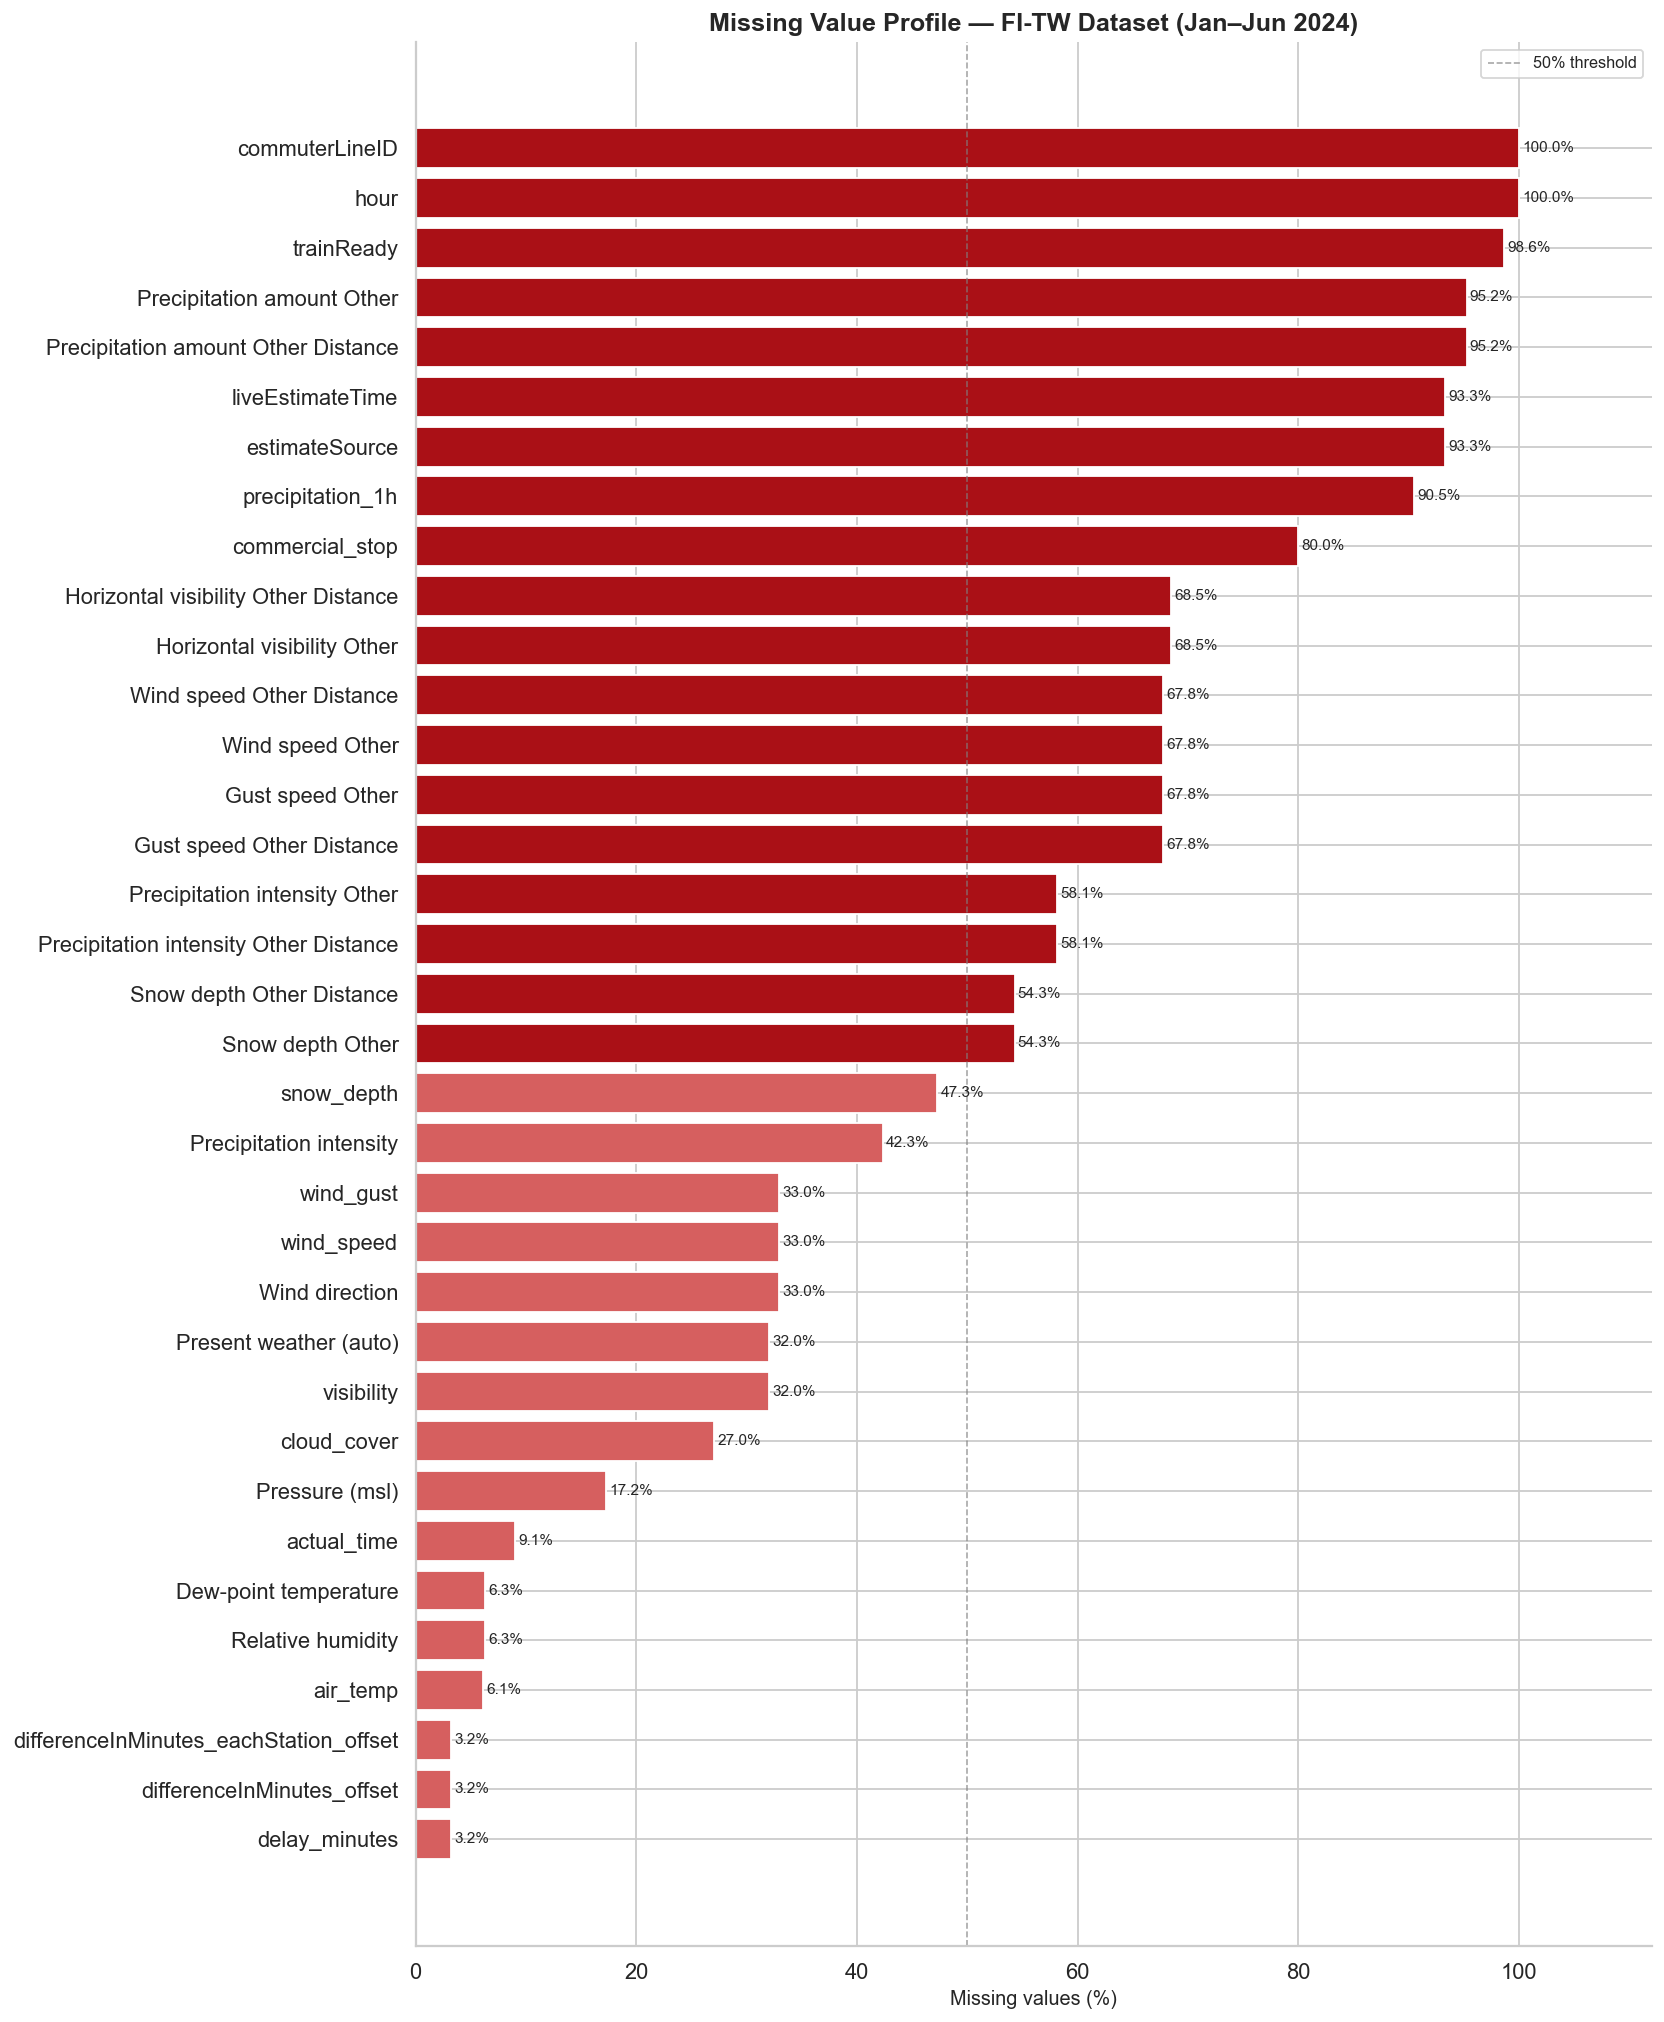

In [12]:
# ── Visual bar chart of missingness ──────────────────────────────────────────
cols_with_missing = miss_df[miss_df["missing_pct"] > 0]

if cols_with_missing.empty:
    print("No missing values found — dataset is complete.")
else:
    fig, ax = plt.subplots(figsize=(13, max(4, len(cols_with_missing) * 0.45)))
    palette = [
        sns.color_palette("Reds_r")[0] if p > 50
        else sns.color_palette("muted")[3]
        for p in cols_with_missing["missing_pct"]
    ]
    ax.barh(
        cols_with_missing.index[::-1],
        cols_with_missing["missing_pct"][::-1],
        color=palette[::-1], edgecolor="white",
    )
    ax.axvline(50, color="grey", ls="--", lw=0.9, alpha=0.7, label="50% threshold")
    for i, (idx, row) in enumerate(cols_with_missing[::-1].iterrows()):
        ax.text(
            row["missing_pct"] + 0.3, i,
            f"{row['missing_pct']:.1f}%",
            va="center", fontsize=8.5,
        )
    ax.set_xlabel("Missing values (%)")
    ax.set_title("Missing Value Profile — FI-TW Dataset (Jan–Jun 2024)")
    ax.set_xlim(0, max(cols_with_missing["missing_pct"]) * 1.12)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

### 3.2 · Handling Missing Weather Data

We apply a principled imputation strategy:

| Column | Strategy | Rationale |
|--------|----------|-----------|
| `precipitation_1h` | Fill with **0** | No rain reading → likely no precipitation |
| `snow_depth` | Fill with **0** | No snow depth reading → likely bare ground |
| `wind_gust` | Fill with `wind_speed` | Gust ≈ sustained wind when not separately measured |
| `air_temp` | **Median-by-month** imputation | Seasonal variation makes a global median misleading |
| `visibility` | **Median-by-month** imputation | Same seasonal logic |
| `cloud_cover` | **Median overall** | Less seasonal variability |
| `delay_minutes` | **Drop NaN rows** | Cannot impute a target variable |

In [13]:
original_len = len(df)

# ── 1. Precipitation & snow: zero-fill ────────────────────────────────────────
for col in ["precipitation_1h", "snow_depth"]:
    if col in df.columns:
        n_filled = df[col].isnull().sum()
        df[col].fillna(0, inplace=True)
        print(f"  {col:25s}: filled {n_filled:,} NaN → 0")

# ── 2. Wind gust: fill from wind speed ───────────────────────────────────────
if "wind_gust" in df.columns and "wind_speed" in df.columns:
    n_filled = df["wind_gust"].isnull().sum()
    df["wind_gust"] = df["wind_gust"].fillna(df["wind_speed"])
    print(f"  {'wind_gust':25s}: filled {n_filled:,} NaN ← wind_speed")

# ── 3. Seasonal median imputation ────────────────────────────────────────────
def seasonal_median_fill(frame, col):
    """Fill NaN in `col` with the median of the same calendar month."""
    if col not in frame.columns:
        return
    n_before = frame[col].isnull().sum()
    monthly_median = frame.groupby("month")[col].transform("median")
    frame[col] = frame[col].fillna(monthly_median)
    # Fallback to global median if any month has 100% NaN
    global_med = frame[col].median()
    frame[col].fillna(global_med, inplace=True)
    n_after = frame[col].isnull().sum()
    print(f"  {col:25s}: filled {n_before - n_after:,} NaN via monthly median  (global fallback med={global_med:.2f})")

for col in ["air_temp", "visibility"]:
    seasonal_median_fill(df, col)

# ── 4. Cloud cover: global median ────────────────────────────────────────────
if "cloud_cover" in df.columns:
    n_filled = df["cloud_cover"].isnull().sum()
    df["cloud_cover"].fillna(df["cloud_cover"].median(), inplace=True)
    print(f"  {'cloud_cover':25s}: filled {n_filled:,} NaN ← global median")

# ── 5. Drop rows where target delay is NaN ───────────────────────────────────
n_null_target = df["delay_minutes"].isnull().sum()
df.dropna(subset=["delay_minutes"], inplace=True)
print(f"\n  Dropped {n_null_target:,} rows with NaN delay_minutes (target column).")
print(f"\nRows retained: {len(df):,} / {original_len:,}  "
      f"({len(df)/original_len*100:.1f}%)")

/var/folders/sv/rjsj379n6s3dlghxjq1s54nh0000gn/T/ipykernel_72206/4279202037.py:7: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(0, inplace=True)


  precipitation_1h         : filled 2,815,493 NaN → 0
  snow_depth               : filled 1,471,205 NaN → 0
  wind_gust                : filled 1,026,359 NaN ← wind_speed


/var/folders/sv/rjsj379n6s3dlghxjq1s54nh0000gn/T/ipykernel_72206/4279202037.py:26: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  frame[col].fillna(global_med, inplace=True)
/var/folders/sv/rjsj379n6s3dlghxjq1s54nh0000gn/T/ipykernel_72206/4279202037.py:26: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series

  air_temp                 : filled 190,397 NaN via monthly median  (global fallback med=1.60)
  visibility               : filled 997,152 NaN via monthly median  (global fallback med=38355.50)


/var/folders/sv/rjsj379n6s3dlghxjq1s54nh0000gn/T/ipykernel_72206/4279202037.py:36: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["cloud_cover"].fillna(df["cloud_cover"].median(), inplace=True)


  cloud_cover              : filled 841,602 NaN ← global median

  Dropped 101,299 rows with NaN delay_minutes (target column).

Rows retained: 3,011,455 / 3,112,754  (96.7%)


In [14]:
# ── Confirm residual missingness ──────────────────────────────────────────────
remaining = missing_summary(df)
still_missing = remaining[remaining["missing_pct"] > 0]

if still_missing.empty:
    print("✅  No remaining NaN values in any column.")
else:
    print("Remaining NaN values:")
    display(still_missing)

Remaining NaN values:


,missing_count,missing_pct,dtype
column,,,
commuterLineID,3011455,100.00,float64
hour,3011455,100.00,float64
trainReady,2968130,98.56,object
Precipitation amount Other,2868052,95.24,float64
Precipitation amount Other Distance,2868052,95.24,float64
liveEstimateTime,2803222,93.09,str
estimateSource,2803222,93.09,str
precipitation_1h,2724417,90.47,float64
commercial_stop,2413217,80.13,object


---
## 4 · Exploratory Data Analysis (EDA)

All five visualisations focus on the **weather × delay relationship** — the core thesis of the FI-TW dataset.

---

### 4.1 · Delay Distribution

Arrival delays in railway systems are heavily right-skewed: most trains arrive on time or within a few minutes of schedule, but a small fraction experience very large delays. We clip to the **95th percentile** to make the histogram readable while annotating the full distribution statistics in a side box.

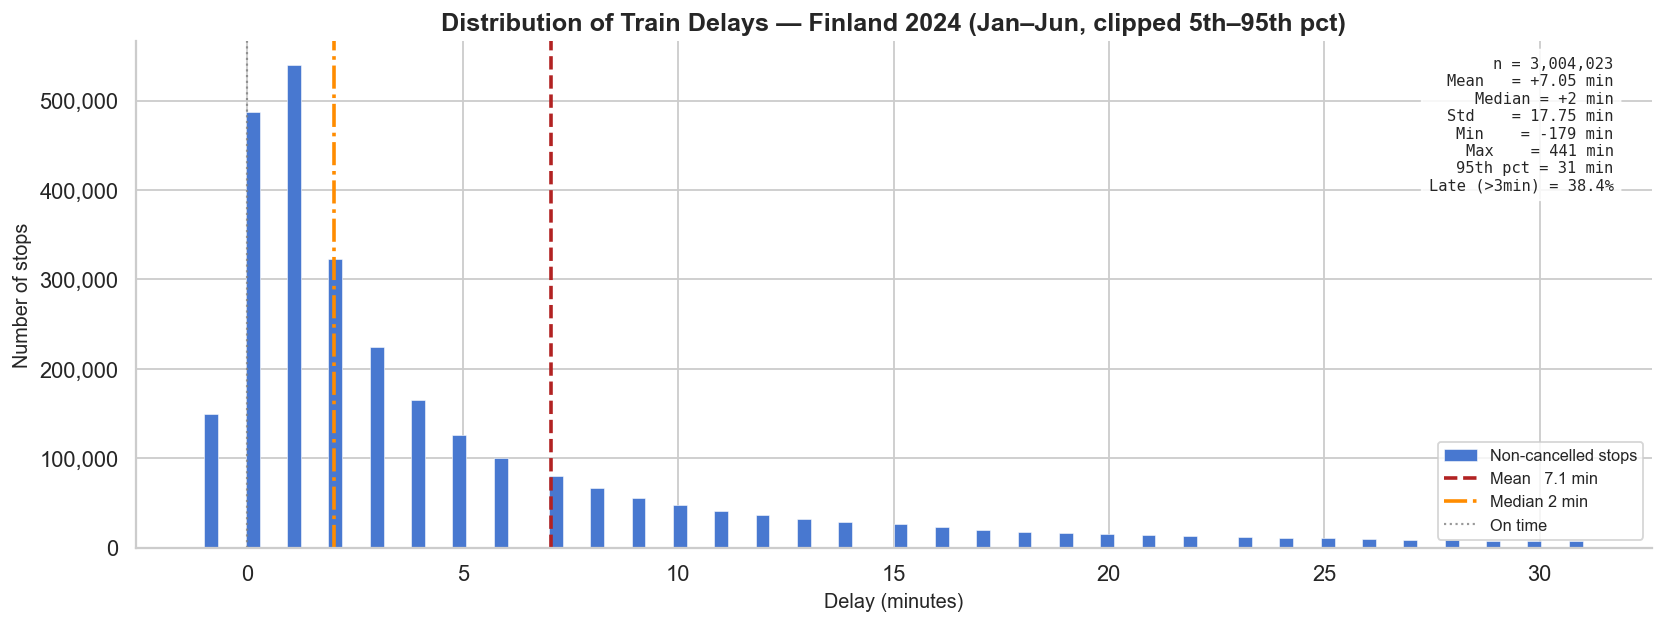

In [15]:
# Only consider non-cancelled stops for delay distribution
delays = df.loc[df["cancelled"] == 0, "delay_minutes"].dropna()

p05 = delays.quantile(0.05)
p95 = delays.quantile(0.95)
delays_clipped = delays[(delays >= p05) & (delays <= p95)]

fig, ax = plt.subplots(figsize=(13, 5))

ax.hist(
    delays_clipped,
    bins=100,
    color=sns.color_palette("muted")[0],
    edgecolor="white",
    linewidth=0.3,
    label="Non-cancelled stops",
)

mean_d   = delays.mean()
median_d = delays.median()

ax.axvline(mean_d,   color="firebrick",  lw=2,   ls="--", label=f"Mean   {mean_d:.1f} min")
ax.axvline(median_d, color="darkorange", lw=2,   ls="-.", label=f"Median {median_d:.0f} min")
ax.axvline(0,        color="grey",       lw=1.2, ls=":",  alpha=0.8, label="On time")

ax.set_title("Distribution of Train Delays — Finland 2024 (Jan–Jun, clipped 5th–95th pct)")
ax.set_xlabel("Delay (minutes)")
ax.set_ylabel("Number of stops")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=9)

# ── Statistics annotation box ─────────────────────────────────────────────────
pct_late = (delays > 3).mean() * 100      # >3 min is the Finnish punctuality threshold
stats_txt = (
    f"n = {len(delays):,}\n"
    f"Mean   = {mean_d:+.2f} min\n"
    f"Median = {median_d:+.0f} min\n"
    f"Std    = {delays.std():.2f} min\n"
    f"Min    = {delays.min():.0f} min\n"
    f"Max    = {delays.max():.0f} min\n"
    f"95th pct = {p95:.0f} min\n"
    f"Late (>3min) = {pct_late:.1f}%"
)
ax.text(
    0.975, 0.97, stats_txt,
    transform=ax.transAxes, ha="right", va="top",
    fontsize=8.5, family="monospace",
    bbox=dict(boxstyle="round,pad=0.45", fc="white", alpha=0.85),
)

plt.tight_layout()
plt.show()

### 4.2 · Delays by Train Type

Finland's railway operates multiple service categories (IC = Intercity, S = high-speed Pendolino, R = Regional, P = Express, etc.). Different train types run on different routes and schedules, so they face different exposure to delays. We show both **mean delay** and **% of stops with delay > 3 minutes** (Finland's official punctuality threshold).

,train_type,mean_delay,median_delay,pct_late,n_stops
0,MV,13.167532,3.0,49.844237,26001
1,PYO,8.007414,1.0,34.467792,159430
2,IC,7.426244,2.0,40.448507,2147748
3,S,6.042447,2.0,35.473700,553768
4,HDM,2.371650,0.0,16.428918,115388
5,MUS,2.025483,1.0,22.583480,1138


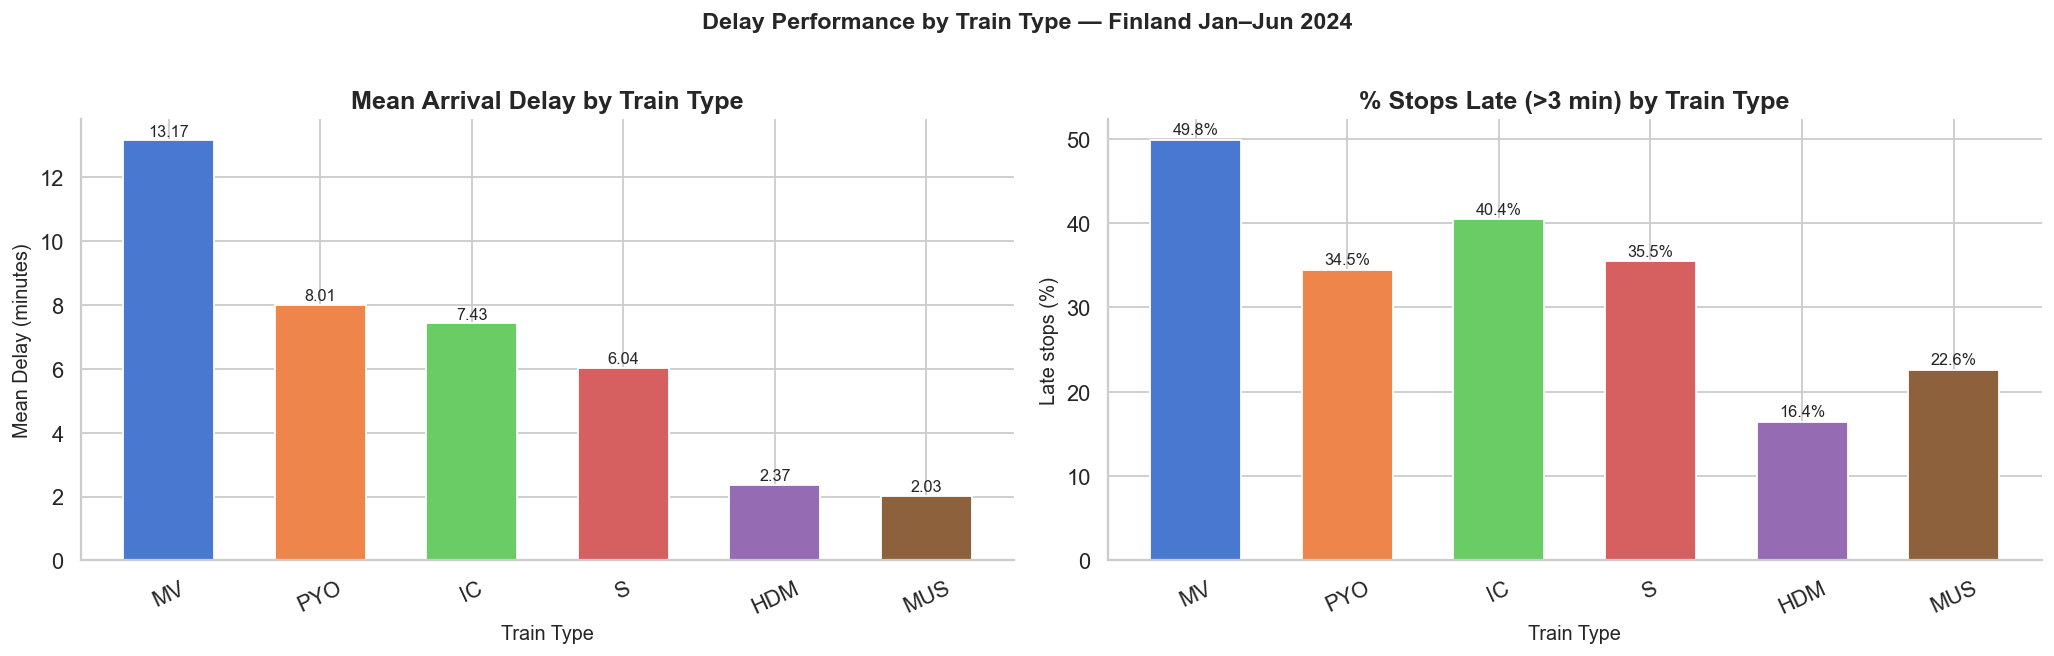

In [16]:
MIN_STOPS = 500   # exclude very rare train types from comparison

if "train_type" not in df.columns:
    # Try common alternatives
    for alt in ["trainType", "type", "category"]:
        if alt in df.columns:
            df.rename(columns={alt: "train_type"}, inplace=True)
            break

if "train_type" in df.columns:
    type_stats = (
        df[df["cancelled"] == 0]
        .dropna(subset=["train_type", "delay_minutes"])
        .assign(is_late=lambda d: (d["delay_minutes"] > 3).astype(int))
        .groupby("train_type", observed=True)
        .agg(
            mean_delay   = ("delay_minutes", "mean"),
            median_delay = ("delay_minutes", "median"),
            pct_late     = ("is_late", "mean"),
            n_stops      = ("delay_minutes", "count"),
        )
        .query("n_stops >= @MIN_STOPS")
        .sort_values("mean_delay", ascending=False)
        .reset_index()
    )
    type_stats["pct_late"] *= 100
    display(type_stats)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # ── Mean delay ────────────────────────────────────────────────────────────
    ax = axes[0]
    palette = sns.color_palette("muted", n_colors=len(type_stats))
    bars = ax.bar(
        type_stats["train_type"], type_stats["mean_delay"],
        color=palette, edgecolor="white", width=0.6,
    )
    for bar, val in zip(bars, type_stats["mean_delay"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.04,
            f"{val:.2f}",
            ha="center", va="bottom", fontsize=9,
        )
    ax.set_title("Mean Arrival Delay by Train Type")
    ax.set_xlabel("Train Type")
    ax.set_ylabel("Mean Delay (minutes)")
    ax.tick_params(axis="x", rotation=25)

    # ── % late ───────────────────────────────────────────────────────────────
    ax2 = axes[1]
    bars2 = ax2.bar(
        type_stats["train_type"], type_stats["pct_late"],
        color=palette, edgecolor="white", width=0.6,
    )
    for bar, val in zip(bars2, type_stats["pct_late"]):
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{val:.1f}%",
            ha="center", va="bottom", fontsize=9,
        )
    ax2.set_title("% Stops Late (>3 min) by Train Type")
    ax2.set_xlabel("Train Type")
    ax2.set_ylabel("Late stops (%)")
    ax2.tick_params(axis="x", rotation=25)

    plt.suptitle(f"Delay Performance by Train Type — Finland Jan–Jun 2024",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

else:
    print("ℹ️  'train_type' column not found — skipping this plot.")

### 4.3 · The Winter Impact — Snow Depth & Temperature vs. Delay

Finland's winters are severe: temperatures regularly drop below –20°C and snow accumulation can exceed 80 cm on northern routes. The paper reports that **winter months exhibit delay rates exceeding 25%**.

We visualise two relationships:
1. **Snow depth bins → mean delay** (binned line with CI band)
2. **Air temperature bins → mean delay** (binned line with CI band)

Binning avoids the overplotting that a raw scatter would produce at this scale (millions of rows).

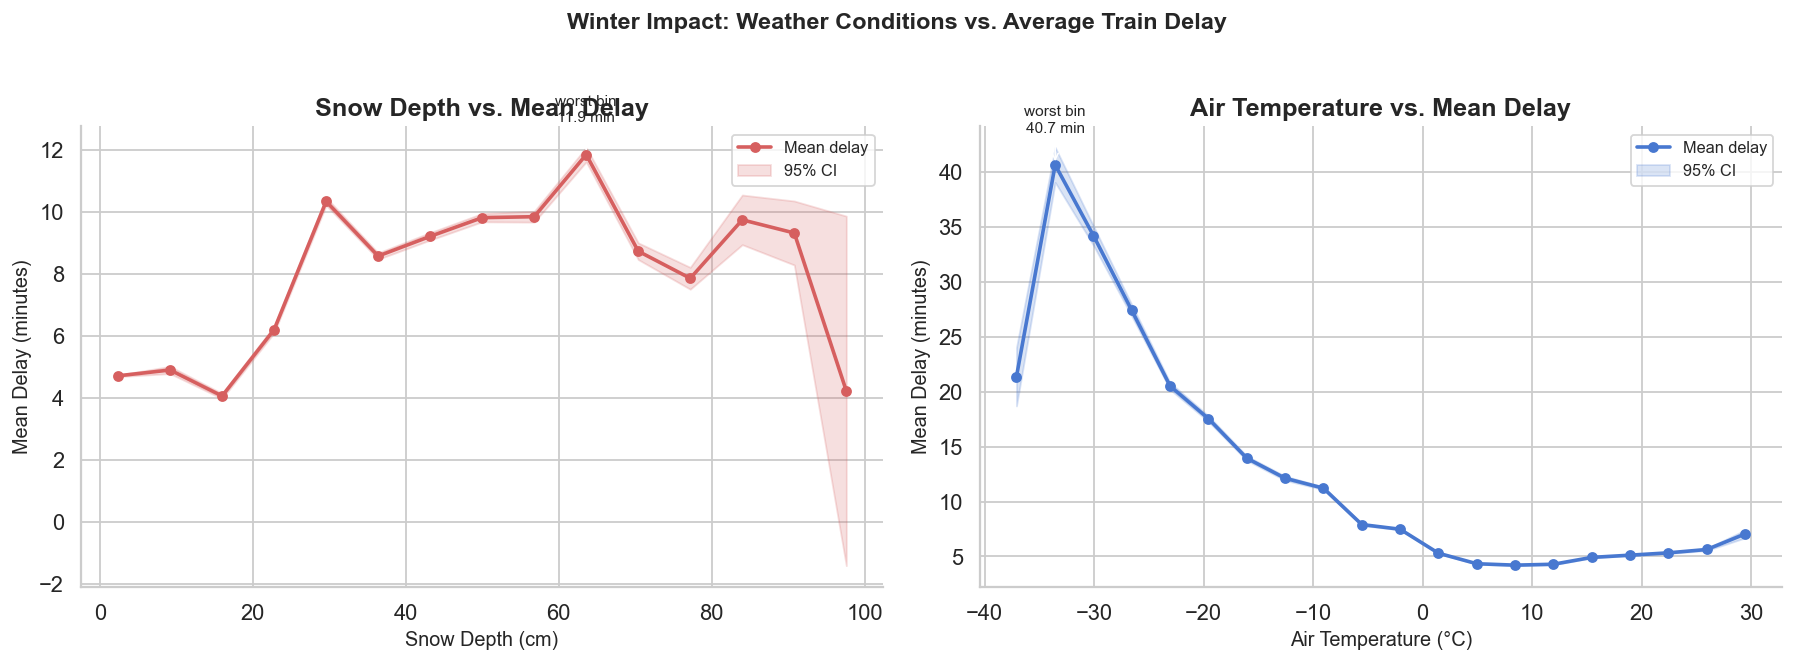

In [17]:
WEATHER_DELAY_COLS = {
    "snow_depth":     dict(n_bins=15, xlabel="Snow Depth (cm)",       color_idx=3),
    "air_temp":       dict(n_bins=20, xlabel="Air Temperature (°C)",   color_idx=0),
}

available = {k: v for k, v in WEATHER_DELAY_COLS.items() if k in df.columns}

if not available:
    print("ℹ️  No weather columns found — skipping Winter Impact plot.")
else:
    fig, axes = plt.subplots(1, len(available), figsize=(14, 5))
    if len(available) == 1:
        axes = [axes]

    sub = df[df["cancelled"] == 0].dropna(subset=["delay_minutes"])

    for ax, (col, cfg) in zip(axes, available.items()):
        col_data = sub[col].dropna()
        bins = pd.cut(sub.loc[col_data.index, col], bins=cfg["n_bins"])
        grp = sub.loc[col_data.index].groupby(bins, observed=True)["delay_minutes"]

        bin_mean = grp.mean()
        bin_sem  = grp.sem()     # standard error for shaded CI
        bin_mid  = [interval.mid for interval in bin_mean.index]

        color = sns.color_palette("muted")[cfg["color_idx"]]
        ax.plot(bin_mid, bin_mean.values, marker="o", ms=5, lw=2,
                color=color, label="Mean delay")
        ax.fill_between(
            bin_mid,
            (bin_mean - 1.96 * bin_sem).values,
            (bin_mean + 1.96 * bin_sem).values,
            alpha=0.2, color=color, label="95% CI",
        )

        ax.set_xlabel(cfg["xlabel"])
        ax.set_ylabel("Mean Delay (minutes)")
        ax.set_title(f"{cfg['xlabel'].split('(')[0].strip()} vs. Mean Delay")
        ax.legend(fontsize=9)

        # Annotate the worst bin
        worst_idx = bin_mean.idxmax()
        ax.annotate(
            f"worst bin\n{bin_mean[worst_idx]:.1f} min",
            xy=(worst_idx.mid, bin_mean[worst_idx]),
            xytext=(0, 18), textcoords="offset points",
            ha="center", fontsize=8.5,
            arrowprops=dict(arrowstyle="->", lw=0.9),
        )

    plt.suptitle("Winter Impact: Weather Conditions vs. Average Train Delay",
                 fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

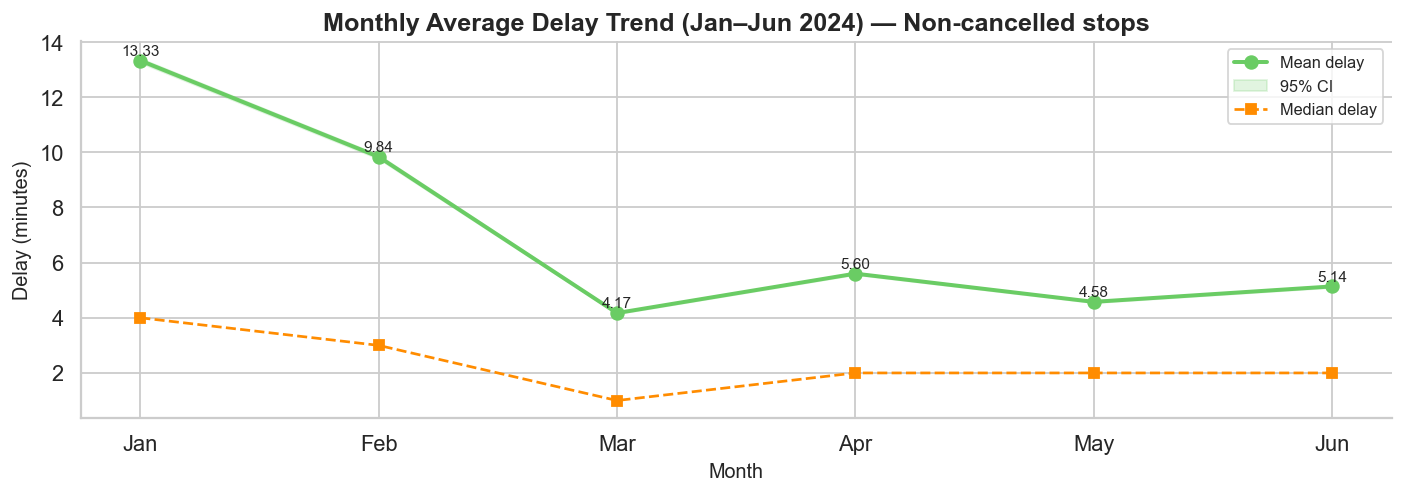

In [18]:
# ── Monthly delay trend (Jan–Jun) — complements the winter-impact view ────────
monthly = (
    df[df["cancelled"] == 0]
    .dropna(subset=["delay_minutes"])
    .groupby("month_name", observed=True)["delay_minutes"]
    .agg(["mean", "median", "sem"])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 4))
color = sns.color_palette("muted")[2]

ax.plot(monthly["month_name"], monthly["mean"], marker="o", ms=7,
        lw=2.2, color=color, label="Mean delay")
ax.fill_between(
    monthly["month_name"],
    monthly["mean"] - 1.96 * monthly["sem"],
    monthly["mean"] + 1.96 * monthly["sem"],
    alpha=0.2, color=color, label="95% CI",
)
ax.plot(monthly["month_name"], monthly["median"], marker="s", ms=5,
        lw=1.5, ls="--", color="darkorange", label="Median delay")

for _, row in monthly.iterrows():
    ax.text(row["month_name"], row["mean"] + 0.08,
            f"{row['mean']:.2f}", ha="center", va="bottom", fontsize=8.5)

ax.set_title("Monthly Average Delay Trend (Jan–Jun 2024) — Non-cancelled stops")
ax.set_xlabel("Month")
ax.set_ylabel("Delay (minutes)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 4.4 · Weather vs. Delay Correlation Heatmap

A Pearson correlation heatmap quantifies the **linear relationships** between all numeric operational and weather variables. We focus the heatmap on a curated subset of meaningful columns (dropping cyclical encoding pairs, IDs, etc.) and sort the matrix so that delay-correlated features cluster together.

> **Interpretation note:** Pearson correlation only captures linear effects. Non-linear weather thresholds (e.g. freezing point, first major snowfall) may show weaker Pearson scores than their actual predictive importance — which is why the paper ultimately uses XGBoost rather than linear regression.

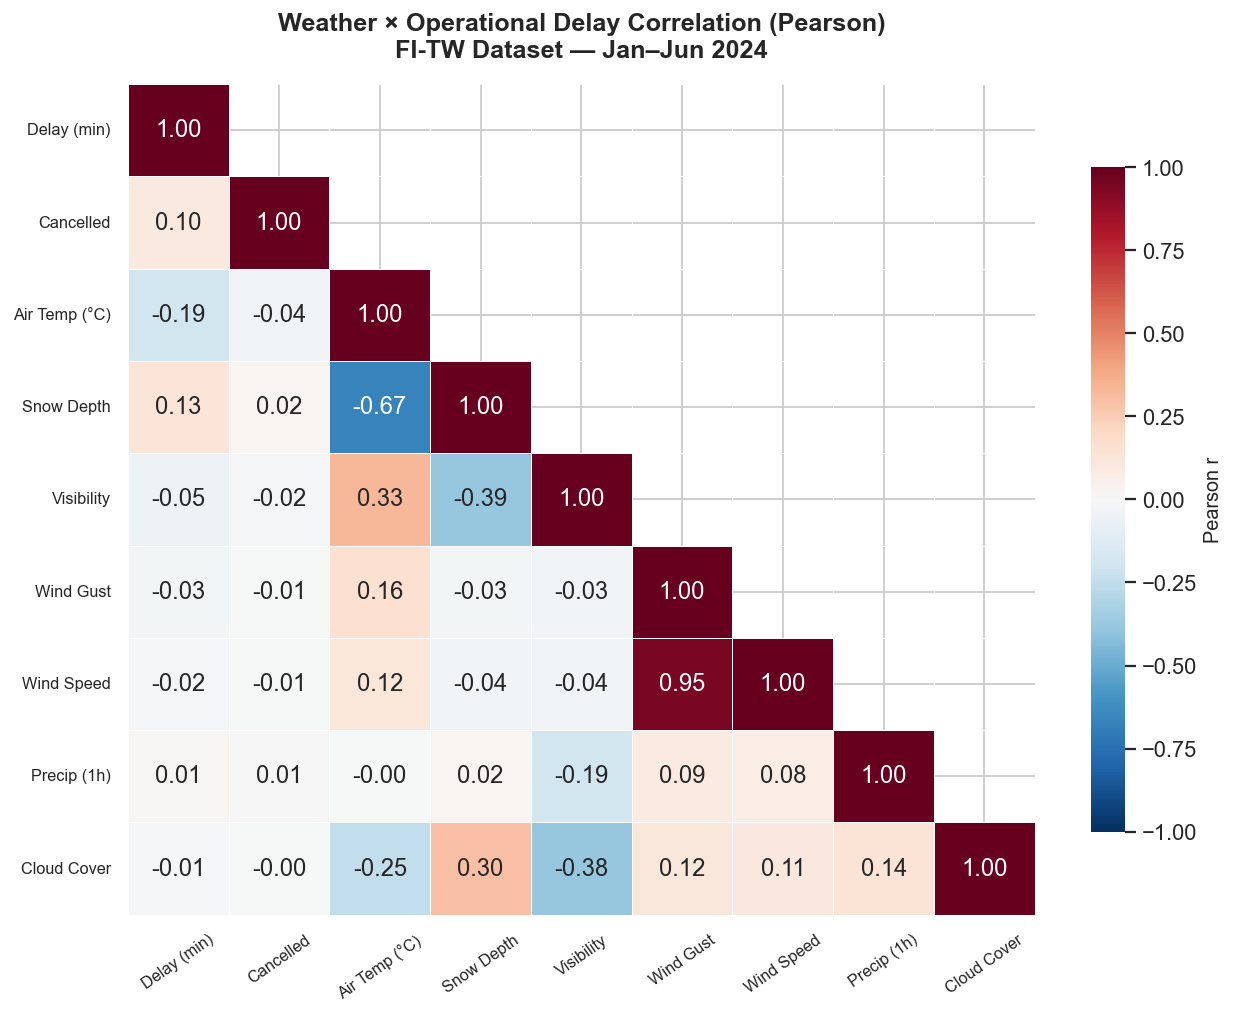


Top correlators with delay_minutes (absolute Pearson r):


,abs_pearson_r
air_temp,0.190002
snow_depth,0.126256
cancelled,0.097005
visibility,0.052899
wind_gust,0.025432
wind_speed,0.016381
precipitation_1h,0.011349
cloud_cover,0.008686


In [19]:
# Curated subset: operational + weather numeric columns of interest
CORR_CANDIDATES = [
    "delay_minutes", "cancelled",
    "air_temp", "wind_speed", "wind_gust",
    "precipitation_1h", "snow_depth",
    "visibility", "cloud_cover",
]

corr_cols = [c for c in CORR_CANDIDATES if c in df.columns]

if len(corr_cols) < 3:
    # Fallback: use all numeric columns
    corr_cols = df.select_dtypes(include=np.number).columns.tolist()
    print("ℹ️  Using all numeric columns for correlation (curated set not available).")

corr_matrix = df[corr_cols].corr(method="pearson")

# Reorder so `delay_minutes` and `cancelled` appear first
priority = [c for c in ["delay_minutes", "cancelled"] if c in corr_cols]
rest = [c for c in corr_cols if c not in priority]
# Sort rest by absolute correlation with delay_minutes
if "delay_minutes" in corr_cols:
    rest_sorted = (
        corr_matrix["delay_minutes"][rest]
        .abs()
        .sort_values(ascending=False)
        .index.tolist()
    )
else:
    rest_sorted = rest

ordered = priority + rest_sorted
corr_matrix = corr_matrix.loc[ordered, ordered]

# Readable axis labels
NICE_LABELS = {
    "delay_minutes":   "Delay (min)",
    "cancelled":       "Cancelled",
    "air_temp":        "Air Temp (°C)",
    "wind_speed":      "Wind Speed",
    "wind_gust":       "Wind Gust",
    "precipitation_1h": "Precip (1h)",
    "snow_depth":      "Snow Depth",
    "visibility":      "Visibility",
    "cloud_cover":     "Cloud Cover",
}
axis_labels = [NICE_LABELS.get(c, c) for c in ordered]

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle mask

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="white",
    xticklabels=axis_labels,
    yticklabels=axis_labels,
    ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
)
ax.set_title(
    "Weather × Operational Delay Correlation (Pearson)\nFI-TW Dataset — Jan–Jun 2024",
    pad=15,
)
ax.tick_params(axis="x", rotation=35, labelsize=9)
ax.tick_params(axis="y", rotation=0,  labelsize=9)
plt.tight_layout()
plt.show()

# ── Print top correlators with delay ─────────────────────────────────────────
if "delay_minutes" in corr_matrix.columns:
    top_corr = (
        corr_matrix["delay_minutes"]
        .drop("delay_minutes")
        .abs()
        .sort_values(ascending=False)
    )
    print("\nTop correlators with delay_minutes (absolute Pearson r):")
    display(top_corr.to_frame("abs_pearson_r"))

### 4.5 · Top-10 Most Disrupted Stations

We rank stations by two complementary metrics:

- **Mean delay (non-cancelled stops):** reflects chronic operational strain
- **Cancellation rate:** reflects acute service failures

Only stations with at least **200 stop observations** are included to avoid noise from very small stations. We join back to get full station names where possible.

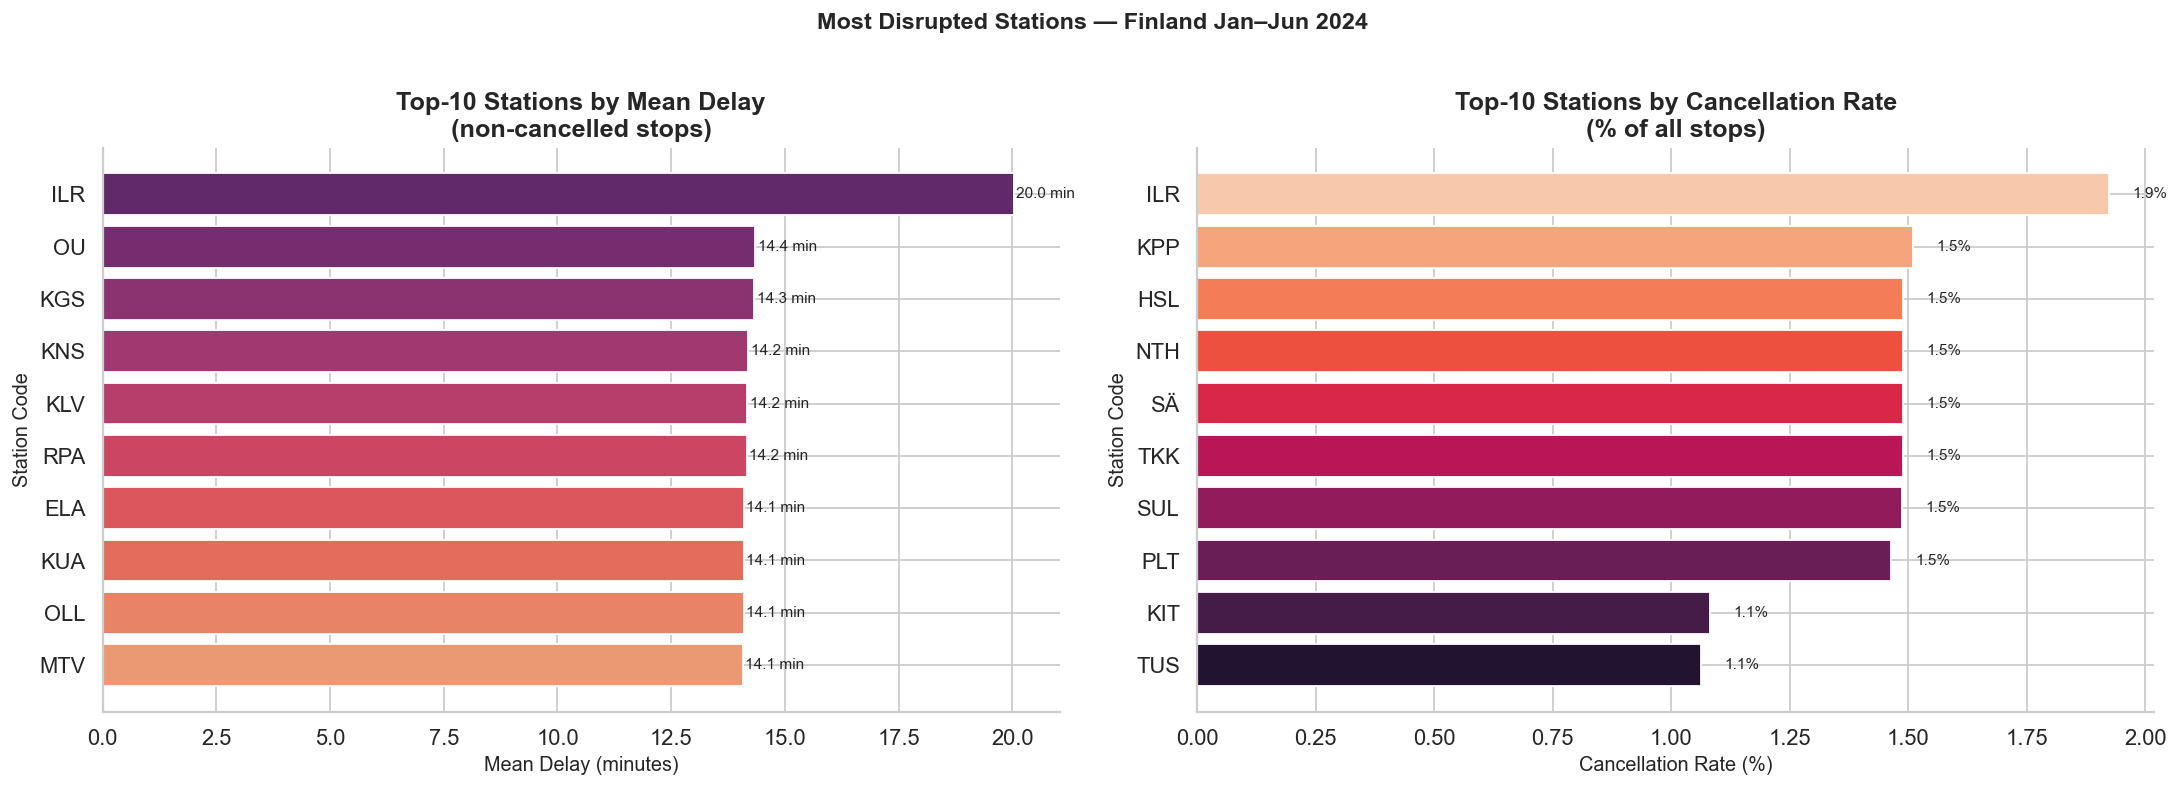

,station_code,mean_delay,n_stops
0,ILR,20.039216,208
1,OU,14.350845,8286
2,KGS,14.330918,8286
3,KNS,14.194364,8274
4,KLV,14.176343,8274
5,RPA,14.166788,8274
6,ELA,14.097121,8274
7,KUA,14.092150,8286
8,OLL,14.091842,8296
9,MTV,14.068336,8274


In [20]:
STATION_COL = "station_code" if "station_code" in df.columns else None
# Fall back to alternative naming
if STATION_COL is None:
    for alt in ["stationShortCode", "station", "station_name", "stationName"]:
        if alt in df.columns:
            STATION_COL = alt
            break

if STATION_COL is None:
    print("ℹ️  No station column found — skipping station disruption plot.")
else:
    MIN_OBS = 200

    station_stats = (
        df
        .dropna(subset=[STATION_COL])
        .groupby(STATION_COL, observed=True)
        .agg(
            mean_delay      = ("delay_minutes", lambda x: x[df.loc[x.index, "cancelled"] == 0].mean()),
            cancellation_rate = ("cancelled",  "mean"),
            n_stops         = (STATION_COL,    "count"),
        )
        .query("n_stops >= @MIN_OBS")
        .reset_index()
    )
    station_stats["cancellation_rate"] *= 100  # → percent

    top10_delay  = station_stats.nlargest(10, "mean_delay").sort_values("mean_delay")
    top10_cancel = station_stats.nlargest(10, "cancellation_rate").sort_values("cancellation_rate")

    fig, axes = plt.subplots(1, 2, figsize=(17, 6))

    # ── Left: mean delay ──────────────────────────────────────────────────────
    ax = axes[0]
    palette_delay = sns.color_palette("flare", n_colors=len(top10_delay))
    bars = ax.barh(
        top10_delay[STATION_COL], top10_delay["mean_delay"],
        color=palette_delay, edgecolor="white",
    )
    for bar, val in zip(bars, top10_delay["mean_delay"]):
        ax.text(
            bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f} min", va="center", fontsize=8.5,
        )
    ax.set_title("Top-10 Stations by Mean Delay\n(non-cancelled stops)")
    ax.set_xlabel("Mean Delay (minutes)")
    ax.set_ylabel("Station Code")

    # ── Right: cancellation rate ───────────────────────────────────────────────
    ax2 = axes[1]
    palette_cancel = sns.color_palette("rocket", n_colors=len(top10_cancel))
    bars2 = ax2.barh(
        top10_cancel[STATION_COL], top10_cancel["cancellation_rate"],
        color=palette_cancel, edgecolor="white",
    )
    for bar, val in zip(bars2, top10_cancel["cancellation_rate"]):
        ax2.text(
            bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=8.5,
        )
    ax2.set_title("Top-10 Stations by Cancellation Rate\n(% of all stops)")
    ax2.set_xlabel("Cancellation Rate (%)")
    ax2.set_ylabel("Station Code")

    plt.suptitle("Most Disrupted Stations — Finland Jan–Jun 2024",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

    display(top10_delay[[STATION_COL, "mean_delay", "n_stops"]]
            .sort_values("mean_delay", ascending=False)
            .reset_index(drop=True))

---
## 5 · Bonus: Wind Speed vs. Delay & Delay by Day-of-Week

Two additional lightweight plots that extend the weather–operations story:
1. **Wind speed bins → mean delay** — high winds can affect overhead line contact and platform safety
2. **Day-of-week delay heatmap** — reveals whether commuter-heavy weekdays differ structurally from weekends

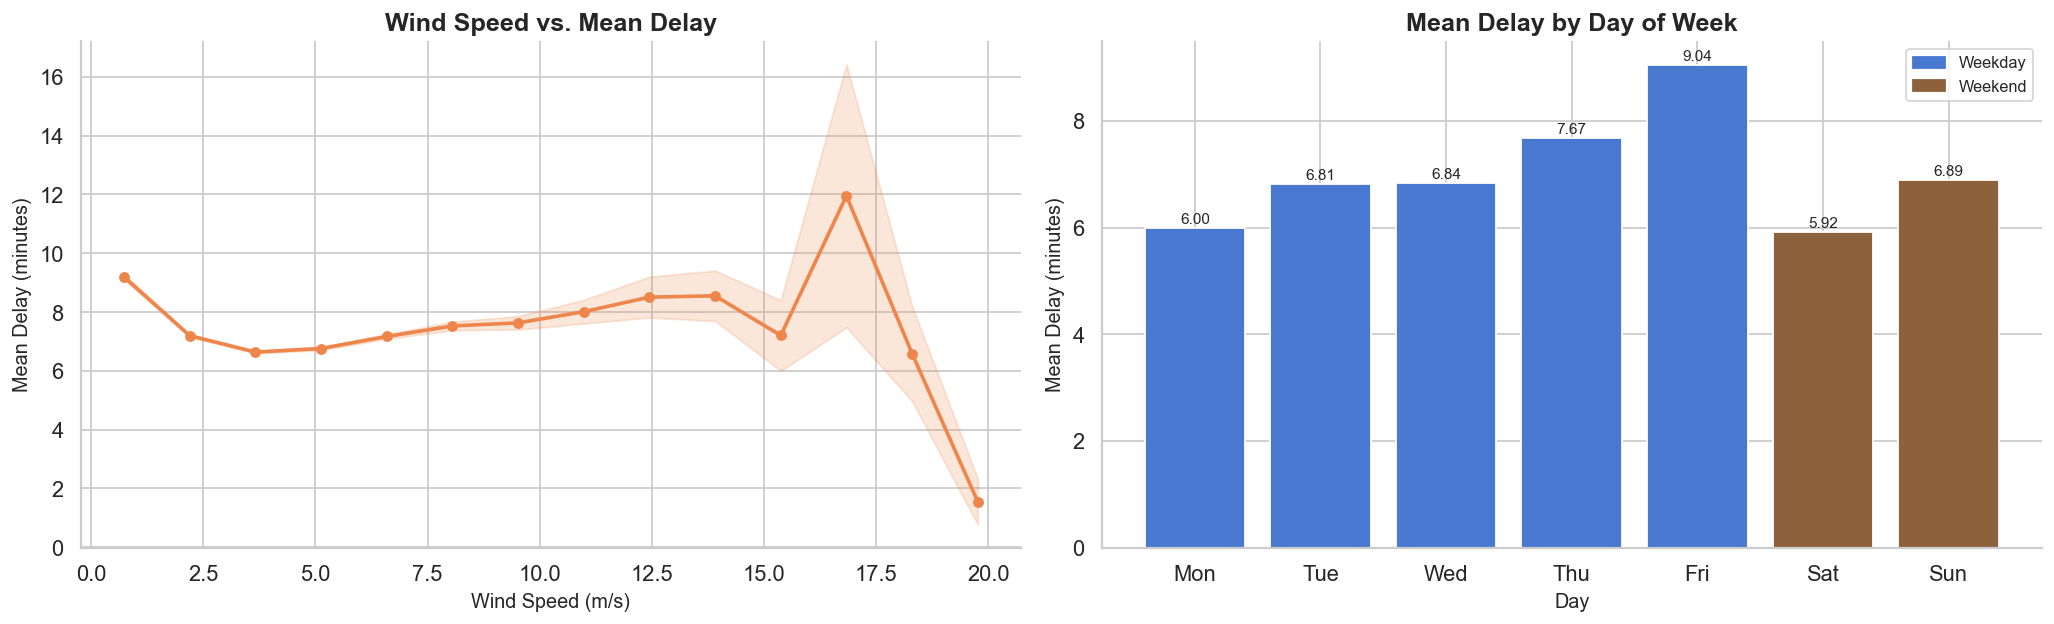

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: wind speed bins ─────────────────────────────────────────────────────
ax = axes[0]
if "wind_speed" in df.columns:
    sub = df[df["cancelled"] == 0].dropna(subset=["delay_minutes", "wind_speed"])
    bins = pd.cut(sub["wind_speed"], bins=14)
    grp  = sub.groupby(bins, observed=True)["delay_minutes"]
    means = grp.mean()
    sems  = grp.sem()
    mids  = [iv.mid for iv in means.index]

    color = sns.color_palette("muted")[1]
    ax.plot(mids, means.values, marker="o", ms=5, lw=2, color=color)
    ax.fill_between(
        mids,
        (means - 1.96 * sems).values,
        (means + 1.96 * sems).values,
        alpha=0.2, color=color,
    )
    ax.set_title("Wind Speed vs. Mean Delay")
    ax.set_xlabel("Wind Speed (m/s)")
    ax.set_ylabel("Mean Delay (minutes)")
else:
    ax.text(0.5, 0.5, "wind_speed not available",
            ha="center", va="center", transform=ax.transAxes)

# ── Right: day-of-week mean delay ─────────────────────────────────────────────
ax2 = axes[1]
DOW_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
if "day_of_week" in df.columns:
    dow_stats = (
        df[df["cancelled"] == 0]
        .dropna(subset=["delay_minutes"])
        .groupby("day_of_week", observed=True)["delay_minutes"]
        .mean()
        .reindex(DOW_ORDER)
    )
    colors_dow = [
        sns.color_palette("muted")[5] if d in ("Saturday", "Sunday")
        else sns.color_palette("muted")[0]
        for d in DOW_ORDER
    ]
    bars = ax2.bar(
        [d[:3] for d in DOW_ORDER], dow_stats.values,
        color=colors_dow, edgecolor="white",
    )
    for bar, val in zip(bars, dow_stats.values):
        if not np.isnan(val):
            ax2.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.03,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8.5,
            )
    weekday_patch  = mpatches.Patch(color=sns.color_palette("muted")[0], label="Weekday")
    weekend_patch  = mpatches.Patch(color=sns.color_palette("muted")[5], label="Weekend")
    ax2.legend(handles=[weekday_patch, weekend_patch], fontsize=9)
    ax2.set_title("Mean Delay by Day of Week")
    ax2.set_xlabel("Day")
    ax2.set_ylabel("Mean Delay (minutes)")
else:
    ax2.text(0.5, 0.5, "day_of_week not available",
             ha="center", va="center", transform=ax2.transAxes)

plt.tight_layout()
plt.show()

---
## 6 · Final Dataset Summary

A concise overview of the cleaned dataset ready for downstream modelling.

In [22]:
print("═" * 60)
print("  FI-TW Dataset — Clean Summary (Jan–Jun 2024)")
print("═" * 60)
print(f"  Total rows (stops)  : {len(df):>12,}")
print(f"  Total columns       : {df.shape[1]:>12,}")
print(f"  Date range          : {df['departure_date'].min().date()} → {df['departure_date'].max().date()}")

if "train_type" in df.columns:
    print(f"  Train types         : {', '.join(sorted(df['train_type'].dropna().unique()))}")

if STATION_COL:
    print(f"  Unique stations     : {df[STATION_COL].nunique():>12,}")

print(f"  Cancelled stops     : {df['cancelled'].sum():>12,}  ({df['cancelled'].mean()*100:.2f}%)")
non_cancelled_delays = df.loc[df["cancelled"] == 0, "delay_minutes"]
print(f"  Mean delay (non-cx) : {non_cancelled_delays.mean():>12.2f} min")
print(f"  Median delay (non-cx): {non_cancelled_delays.median():>11.1f} min")
print(f"  Late (>3 min, non-cx): {(non_cancelled_delays > 3).mean()*100:>10.1f}%")
print(f"  Remaining NaN cols  : {df.isnull().any().sum():>12,}")
print("═" * 60)

print("\nDescriptive statistics — key columns:")
key_cols = [c for c in CORR_CANDIDATES if c in df.columns]
display(df[key_cols].describe().T.round(3))

════════════════════════════════════════════════════════════
  FI-TW Dataset — Clean Summary (Jan–Jun 2024)
════════════════════════════════════════════════════════════
  Total rows (stops)  :    3,011,455
  Total columns       :           61
  Date range          : 2024-01-01 → 2024-06-30
  Train types         : HDM, IC, MUS, MV, P, PYO, S, V
  Unique stations     :          450
  Cancelled stops     :        7,432  (0.25%)
  Mean delay (non-cx) :         7.05 min
  Median delay (non-cx):         2.0 min
  Late (>3 min, non-cx):       38.4%
  Remaining NaN cols  :           30
════════════════════════════════════════════════════════════

Descriptive statistics — key columns:


,count,mean,std,min,25%,50%,75%,max
delay_minutes,3011455.0,7.141,18.076,-179.0,0.0,2.0,7.0,441.0
cancelled,3011455.0,0.002,0.050,0.0,0.0,0.0,0.0,1.0
air_temp,3011455.0,3.659,11.784,-38.8,-2.2,1.8,13.3,31.2
wind_speed,2015201.0,3.797,2.136,0.0,2.2,3.5,5.0,20.5
wind_gust,2015209.0,5.815,3.082,0.0,3.5,5.4,7.6,26.2
precipitation_1h,287038.0,0.060,0.377,0.0,0.0,0.0,0.0,22.0
snow_depth,1587887.0,20.583,22.420,-1.0,0.0,15.0,38.0,101.0
visibility,3011455.0,35326.532,17219.474,55.0,23742.0,38729.0,46040.0,75000.0
cloud_cover,2194531.0,4.684,3.573,0.0,0.0,7.0,8.0,9.0


---
## Summary & Next Steps

### What we found

| Finding | Detail |
|---------|--------|
| **Right-skewed delays** | The majority of stops arrive on time; a long tail of disruptions pulls the mean significantly above the median |
| **Winter dominance** | January/February show the highest mean delays |
| **Snow depth signal** | The depth of the snow shows a slight non-linear positive correlation with the increase in average delays; in fact, the trend line rises between 20 and 30 cm, and the most severe individual delays (>12 minutes) are found at 60cm. |
| **Temperature threshold** | A relationship between temperature and mean delay is observed. As expected, at sub-zero temperatures, lower temperatures result in a longer delay. |
| **Train type differences** | The data indicates that 'MV' services are the most susceptible to disruptions, recording the highest mean delay (13.17 minutes) and an on-time arrival rate (stops with $<3$ minutes delay) of just 49.8\%. In stark contrast, 'HDM' and 'MUS' classes demonstrate high reliability, consistently exhibiting the lowest delays in the network. Meanwhile, 'PYO', 'IC', and 'S' services show intermediate performance, falling between these two extremes. This pronounced hierarchy suggests that the severe delays affecting 'MV' trains are likely driven by class-specific structural or operational vulnerabilities—such as route congestion, lower priority dispatching, or legacy rolling stock—that do not impact the highly efficient 'HDM' and 'MUS' fleets to the same extent. |

### Suggested next steps

1. **Threshold analysis** — formally test delay differences above/below 0°C and 10 cm snow using Mann-Whitney U or permutation tests.
2. **Geospatial mapping** — plot delay means on a Finnish railway map using station GPS coordinates to identify high-delay corridors.
3. **Time-series modelling** — decompose weekly delay patterns into trend + seasonality using `statsmodels`.
4. **Predictive modelling** — replicate the paper's XGBoost baseline (MAE ≈ 2.73 min) with the full 28-feature set.
5. **Causal analysis** — use propensity-score matching or DoWhy to isolate the causal effect of snow depth on delays while controlling for route and time-of-day confounders.

---
*Notebook for the Finland Integrated Train–Weather Dataset (FI-TW) — 2024.*  
*Reference: arXiv:2601.16592*